In [15]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [16]:
data = []
labels = []
file_name = []

dataset_path = "dataset/"

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    if not os.path.isdir(full_path):
        continue  # Lewati jika bukan folder

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

In [17]:
def baseline(img):
    if len(img.shape) == 3:  # kalau RGB/BGR
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    img = cv.resize(img, (128, 128))
    return img

# apply ke semua data
dataPreprocessed = [baseline(img) for img in data]

In [18]:
from collections import Counter

# -----------------------------
# 1. Menampilkan Jumlah Data
print("Jumlah total gambar:", len(data))
print("Jumlah kelas:", len(np.unique(labels)))
print("Distribusi per kelas:", Counter(labels))

Jumlah total gambar: 200
Jumlah kelas: 2
Distribusi per kelas: Counter({np.str_('good'): 100, np.str_('very_poor'): 100})


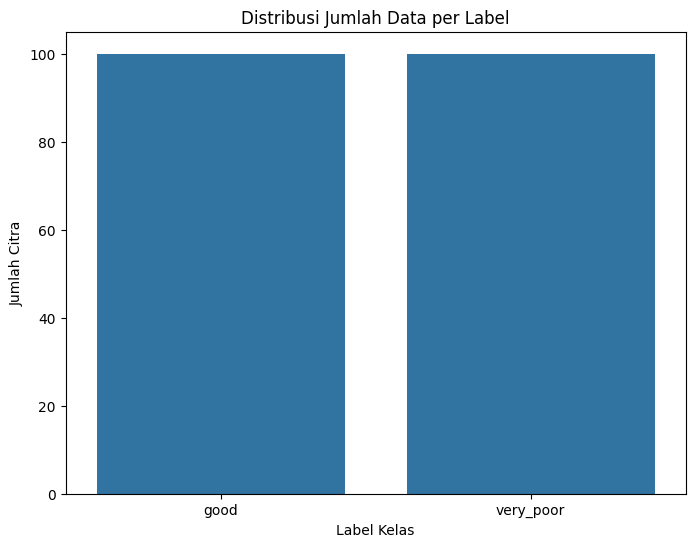

Total jumlah citra dalam dataset: 200
Total jumlah label dalam dataset: 200
Jumlah kelas unik: 2

Jumlah citra per kelas:
good         100
very_poor    100
Name: count, dtype: int64


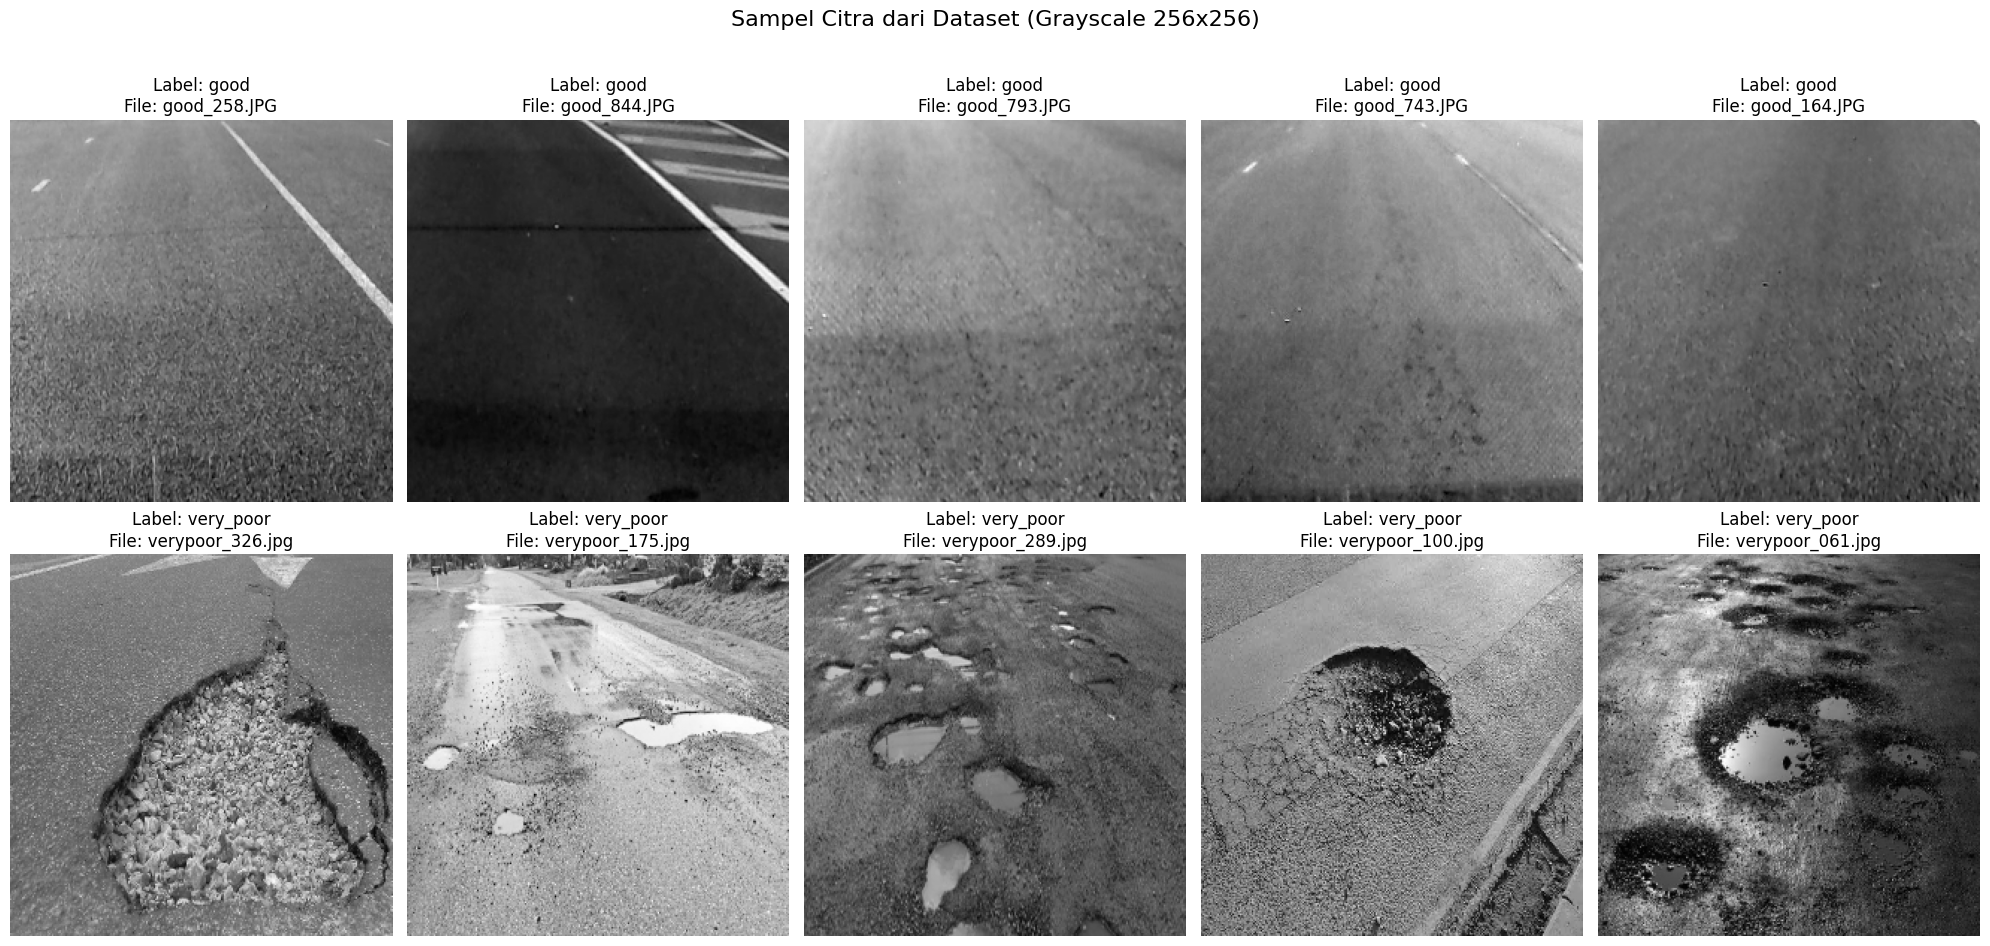

In [19]:
# Mengubah list labels menjadi pandas Series untuk memudahkan penghitungan
label_series = pd.Series(labels)

# Menghitung jumlah kemunculan setiap label
label_counts = label_series.value_counts()

# Membuat diagram batang
plt.figure(figsize=(8, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Distribusi Jumlah Data per Label')
plt.xlabel('Label Kelas')
plt.ylabel('Jumlah Citra')
plt.show()

# Menampilkan jumlah data dan label secara keseluruhan
print(f"Total jumlah citra dalam dataset: {len(data)}")
print(f"Total jumlah label dalam dataset: {len(labels)}")
print(f"Jumlah kelas unik: {len(label_counts)}")
print("\nJumlah citra per kelas:")
print(label_counts)

# Mendapatkan indeks untuk kelas 'good' dan 'very_poor'
normal_indices = np.where(labels == 'good')[0]
tumor_indices = np.where(labels == 'very_poor')[0]

# Mengambil 5 sampel acak jika jumlahnya lebih dari 5, atau semua sampel jika kurang dari 5
num_samples_to_show = 5
if len(normal_indices) >= num_samples_to_show:
    sample_normal_indices = np.random.choice(normal_indices, num_samples_to_show, replace=False)
else:
    sample_normal_indices = normal_indices

if len(tumor_indices) >= num_samples_to_show:
    sample_tumor_indices = np.random.choice(tumor_indices, num_samples_to_show, replace=False)
else:
    sample_tumor_indices = tumor_indices
    
# Menggabungkan indeks sampel
sample_indices = np.concatenate((sample_normal_indices, sample_tumor_indices))

# Menampilkan citra sampel
plt.figure(figsize=(20, 10))
plt.suptitle('Sampel Citra dari Dataset (Grayscale 256x256)', fontsize=16)
for i, index in enumerate(sample_indices):
    plt.subplot(2, num_samples_to_show, i + 1)
    plt.imshow(data[index], cmap='gray') # Menampilkan citra grayscale
    plt.title(f"Label: {labels[index]}\nFile: {file_name[index]}")
    plt.axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Menyesuaikan layout agar supertitle tidak tumpang tindih
plt.show()

In [20]:
def medianFilterData(data, size=3):
    height, width = data.shape
    pad = size // 2

    padded = np.pad(data, pad, mode='edge')
    canvas = np.zeros_like(data)

    for i in range(height):
        for j in range(width):

            region = padded[i:i+size, j:j+size]

            values = region.flatten().tolist()
            values.sort()

            n = len(values)

            if n % 2 == 1:
                median_val = values[n // 2]
            else:
                median_val = (values[n//2 - 1] + values[n//2]) / 2

            canvas[i,j] = median_val

    return canvas

In [21]:
def sharpeningData(data):

    kernel = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ])

    size = kernel.shape[0]
    pad = size // 2

    padded = np.pad(data, pad, mode='constant')
    canvas = np.zeros_like(data, dtype=np.float32)

    height, width = data.shape

    for i in range(height):
        for j in range(width):

            total = 0

            for m in range(size):
                for n in range(size):
                    total += padded[i+m, j+n] * kernel[m,n]

            canvas[i,j] = total

    canvas = np.clip(canvas, 0, 255)

    return canvas.astype(np.uint8)

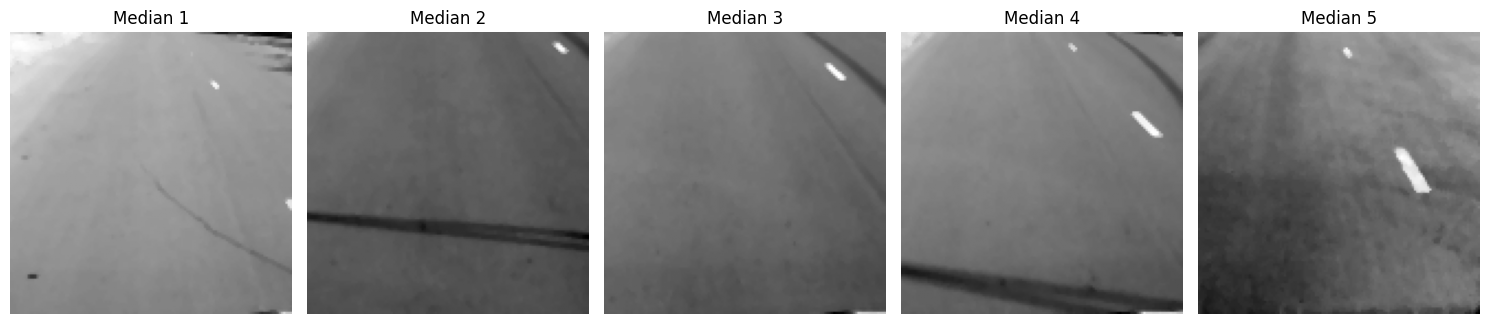

In [22]:
# Proses median filter untuk 5 gambar pertama
median_results = []

for i in range(5):
    median_results.append(medianFilterData(dataPreprocessed[i]))

plt.figure(figsize=(15, 8))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(median_results[i], cmap='gray')
    plt.title(f'Median {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

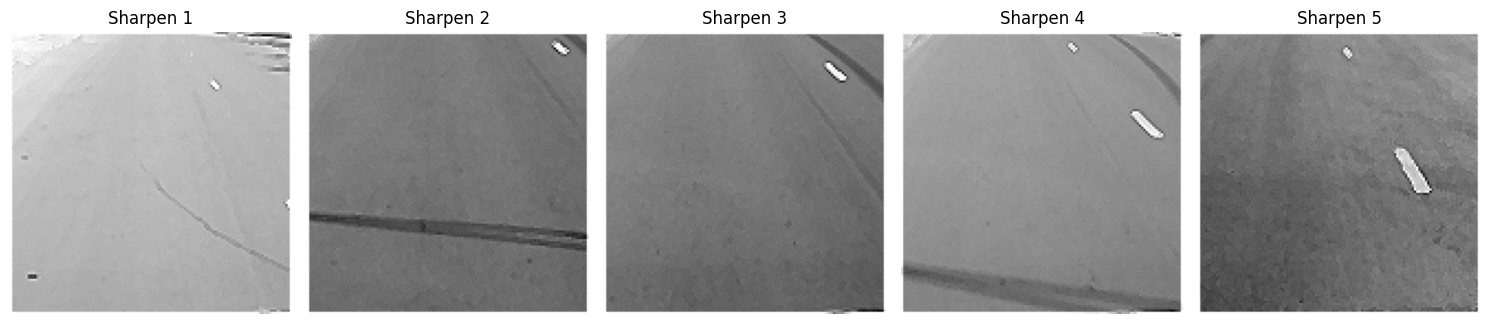

In [37]:
# Proses sharpening dari hasil median filter
dataPreprocessed = []

for i in range(5):
    dataPreprocessed.append(sharpeningData(median_results[i]))

plt.figure(figsize=(15, 8))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(dataPreprocessed[i], cmap='gray')
    plt.title(f'Sharpen {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [59]:
dataPreprocessed = [
    sharpeningData(medianFilterData(img))
    for img in data
]

In [60]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [61]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

In [62]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

In [63]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

In [64]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

In [65]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

In [66]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

In [67]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [68]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [69]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


In [70]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [71]:
for i in range(len(dataPreprocessed)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [72]:
for i in range(len(dataPreprocessed)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [73]:
for i in range(len(dataPreprocessed)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [74]:
for i in range(len(dataPreprocessed)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [75]:
for i in range(len(dataPreprocessed)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [76]:
for i in range(len(dataPreprocessed)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

In [77]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,good_004.JPG,good,76.596170,201.071065,174.674203,217.783622,0.358542,0.338749,0.358033,0.344526,...,0.002425,0.002326,0.048892,0.048287,0.049240,0.048225,0.886663,0.689361,0.743546,0.663542
1,good_005.JPG,good,73.009620,132.351895,74.188664,137.587389,0.423896,0.409561,0.437663,0.404355,...,0.006145,0.005514,0.075425,0.075122,0.078387,0.074256,0.773803,0.499447,0.770086,0.479646
2,good_006.JPG,good,95.115916,189.264022,128.032690,202.290796,0.372857,0.366037,0.385985,0.359150,...,0.003339,0.003112,0.056278,0.056687,0.057783,0.055786,0.784979,0.497027,0.711787,0.462408
3,good_007.JPG,good,102.145006,198.410227,144.979213,225.542837,0.384113,0.367831,0.384546,0.359515,...,0.002928,0.002716,0.053211,0.053091,0.054111,0.052114,0.841918,0.660662,0.777637,0.614258
4,good_010.JPG,good,76.491912,117.101976,73.349877,124.185990,0.299258,0.287583,0.310144,0.285852,...,0.002216,0.002072,0.045840,0.045264,0.047074,0.045521,0.788243,0.636183,0.796941,0.614174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,verypoor_309.jpg,very_poor,710.187990,850.431988,647.933548,728.290980,0.102605,0.090407,0.108165,0.094276,...,0.000153,0.000136,0.011964,0.011337,0.012357,0.011674,0.789936,0.744356,0.808692,0.781059
196,verypoor_314.jpg,very_poor,1337.173009,1549.139116,1320.407843,1426.248920,0.096478,0.080562,0.093991,0.086249,...,0.000170,0.000157,0.013077,0.012183,0.013056,0.012517,0.568060,0.489477,0.572687,0.529995
197,verypoor_323.jpg,very_poor,1224.063159,1423.515709,1354.709988,1440.847136,0.075272,0.063460,0.071746,0.060276,...,0.000097,0.000069,0.009758,0.008516,0.009829,0.008300,0.817498,0.785484,0.797747,0.782872
198,verypoor_326.jpg,very_poor,1626.741268,1900.951403,1678.005714,1876.182068,0.083670,0.067362,0.079030,0.067687,...,0.000215,0.000192,0.015369,0.013811,0.014658,0.013869,0.527298,0.429803,0.508569,0.437233


<Axes: >

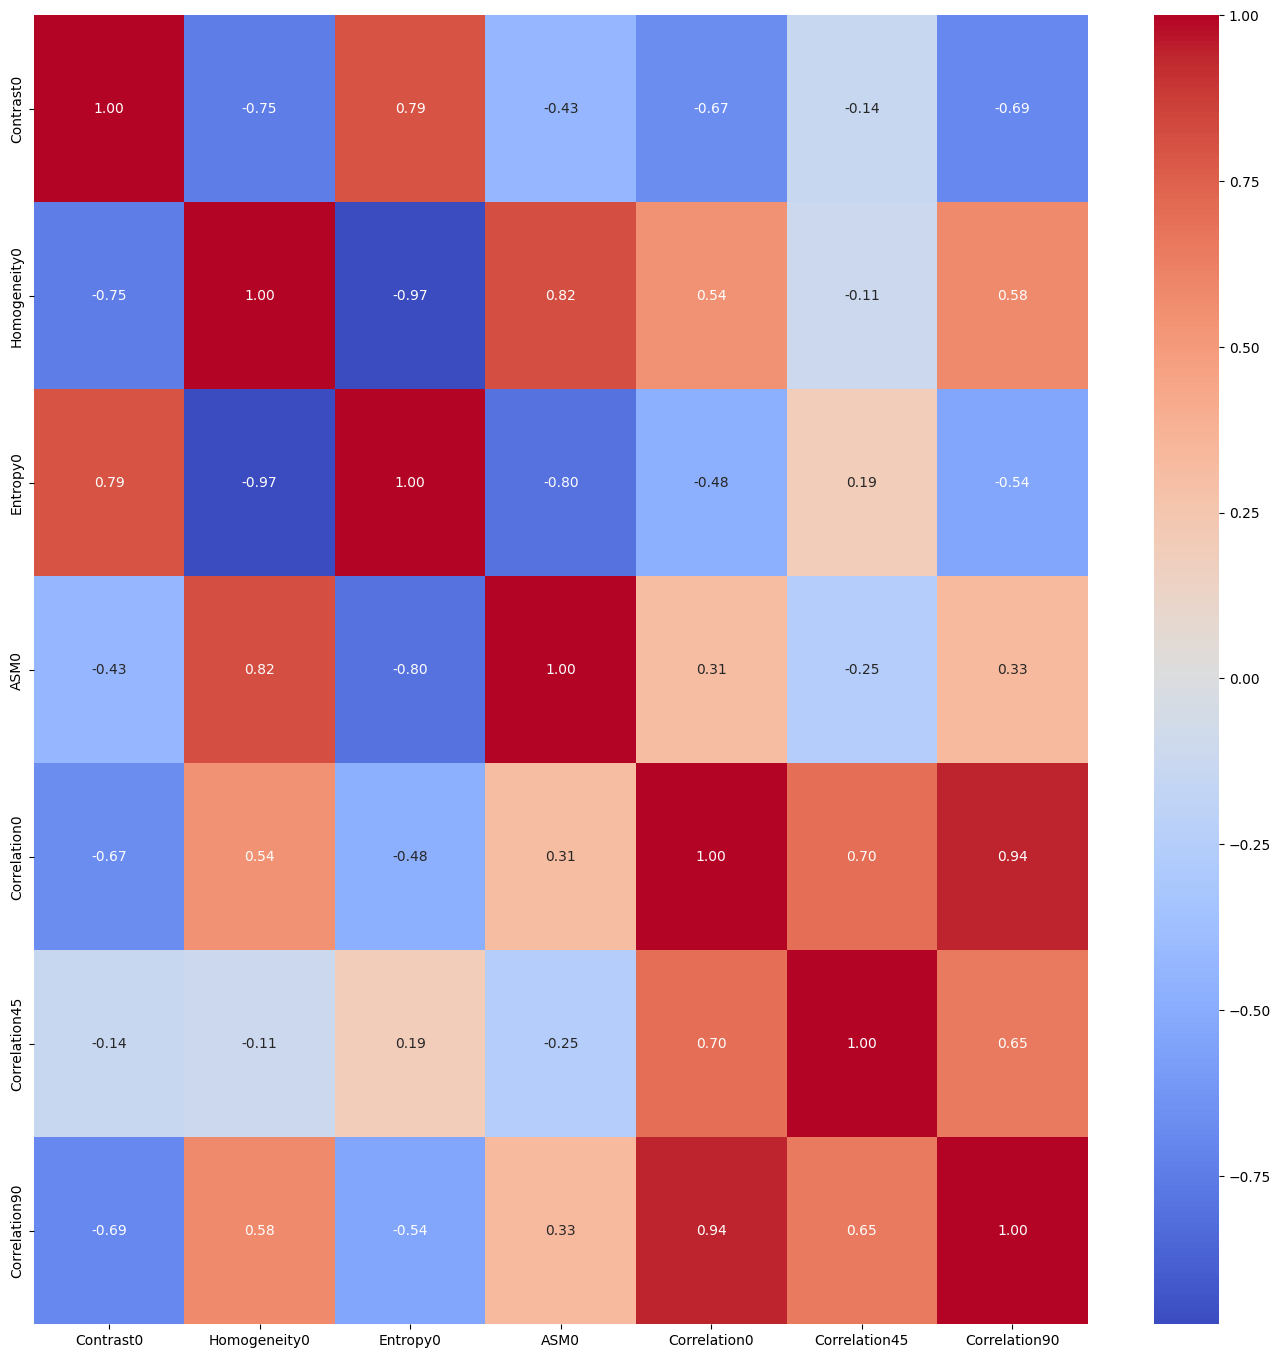

In [88]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [79]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(160, 7)
(40, 7)


In [80]:
# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [81]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [82]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

        good       1.00      1.00      1.00        79
   very_poor       1.00      1.00      1.00        81

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160

[[79  0]
 [ 0 81]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

        good       1.00      0.95      0.98        21
   very_poor       0.95      1.00      0.97        19

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40

[[20  1]
 [ 0 19]]
Accuracy: 0.975


In [83]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

        good       1.00      1.00      1.00        79
   very_poor       1.00      1.00      1.00        81

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160

[[79  0]
 [ 0 81]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

        good       1.00      0.95      0.98        21
   very_poor       0.95      1.00      0.97        19

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40

[[20  1]
 [ 0 19]]
Accuracy: 0.975


In [84]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
              precision    recall  f1-score   support

        good       0.98      1.00      0.99        79
   very_poor       1.00      0.98      0.99        81

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160

[[79  0]
 [ 2 79]]
Accuracy: 0.9875

------Testing Set------
              precision    recall  f1-score   support

        good       1.00      0.95      0.98        21
   very_poor       0.95      1.00      0.97        19

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40

[[20  1]
 [ 0 19]]
Accuracy: 0.975


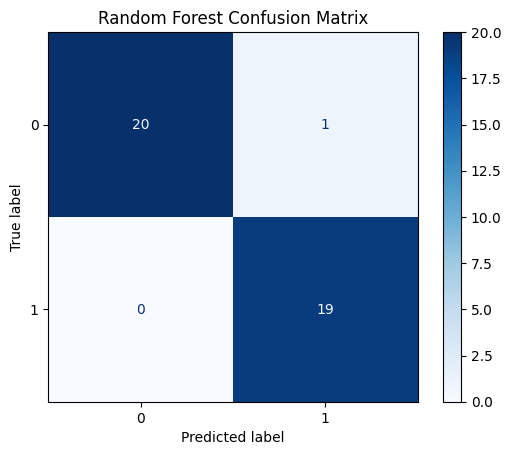

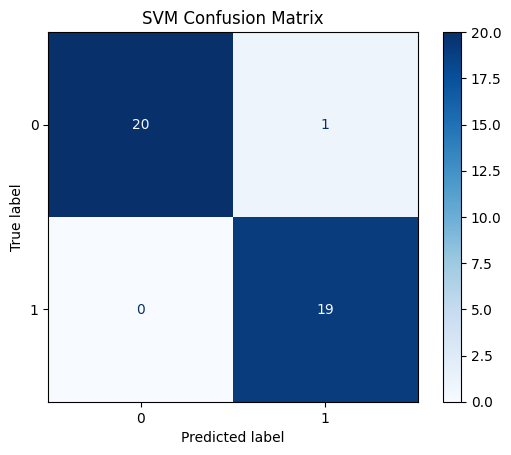

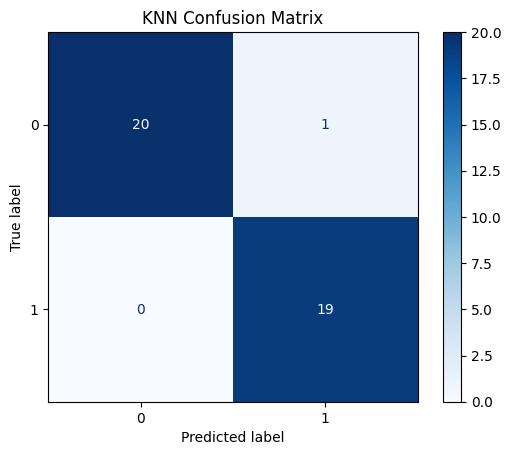

In [85]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")